In [17]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from tqdm import tqdm

In [18]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [19]:
DATA_ROOT = Path("/home/n.bezborodov/ai/lab2/data")

train_img_dir = DATA_ROOT / "tiff" / "train"
train_mask_dir = DATA_ROOT / "tiff" / "train_labels"

val_img_dir = DATA_ROOT / "tiff" / "val"
val_mask_dir = DATA_ROOT / "tiff" / "val_labels"

test_img_dir = DATA_ROOT / "tiff" / "test"
test_mask_dir = DATA_ROOT / "tiff" / "test_labels"

print("train:", len(list(train_img_dir.glob("*"))), len(list(train_mask_dir.glob("*"))))
print("val  :", len(list(val_img_dir.glob("*"))), len(list(val_mask_dir.glob("*"))))
print("test :", len(list(test_img_dir.glob("*"))), len(list(test_mask_dir.glob("*"))))

train: 1108 1108
val  : 14 14
test : 49 49


In [20]:
TILE_SIZE = 512
STRIDE = 256

BATCH_SIZE = 6
NUM_WORKERS = 4

LR = 3e-4
NUM_EPOCHS = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [21]:
def generate_positions(size, tile_size, stride):
    positions = list(range(0, size - tile_size + 1, stride))
    if not positions:
        return [0]
    if positions[-1] != size - tile_size:
        positions.append(size - tile_size)
    return positions

In [22]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2(),
])

In [23]:
class RoadsWindowDataset(Dataset):
    def __init__(self, images_dir, masks_dir, tile_size=512, stride=256, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.tile_size = tile_size
        self.stride = stride
        self.transform = transform

        self.image_paths = sorted(self.images_dir.glob("*"))
        self.mask_paths = sorted(self.masks_dir.glob("*"))

        assert len(self.image_paths) == len(self.mask_paths), "images/masks count mismatch"

        self.samples = []

        for img_path, mask_path in zip(self.image_paths, self.mask_paths):
            mask = tiff.imread(str(mask_path))

            if mask.ndim == 3:
                mask = mask[..., 0]

            h, w = mask.shape[:2]
            ys = generate_positions(h, self.tile_size, self.stride)
            xs = generate_positions(w, self.tile_size, self.stride)

            for y in ys:
                for x in xs:
                    self.samples.append((img_path, mask_path, x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.samples[idx]

        image = tiff.imread(str(img_path))
        mask = tiff.imread(str(mask_path))

        if image.ndim == 3 and image.shape[0] in [3, 4] and image.shape[-1] not in [3, 4]:
            image = np.transpose(image, (1, 2, 0))

        if mask.ndim == 3:
            mask = mask[..., 0]

        image = image[y:y + self.tile_size, x:x + self.tile_size]
        mask = mask[y:y + self.tile_size, x:x + self.tile_size]

        image = image.astype(np.uint8)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.unsqueeze(0)

In [24]:
train_dataset = RoadsWindowDataset(
    images_dir=train_img_dir,
    masks_dir=train_mask_dir,
    tile_size=512,
    stride=256,
    transform=train_transform
)

val_dataset = RoadsWindowDataset(
    images_dir=val_img_dir,
    masks_dir=val_mask_dir,
    tile_size=512,
    stride=256,
    transform=val_transform
)

test_dataset = RoadsWindowDataset(
    images_dir=test_img_dir,
    masks_dir=test_mask_dir,
    tile_size=512,
    stride=256,
    transform=val_transform
)

print("train windows:", len(train_dataset))
print("val windows  :", len(val_dataset))
print("test windows :", len(test_dataset))

train windows: 27700
val windows  : 350
test windows : 1225


In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

torch.Size([6, 3, 512, 512]) torch.Size([6, 1, 512, 512])


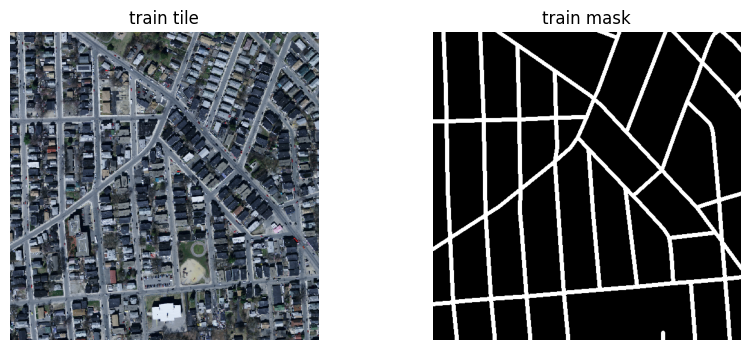

In [26]:
images, masks = next(iter(train_loader))
print(images.shape, masks.shape)

img = images[0].permute(1, 2, 0).cpu().numpy()
msk = masks[0, 0].cpu().numpy()

img = (img - img.min()) / (img.max() - img.min() + 1e-8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("train tile")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(msk, cmap="gray")
plt.title("train mask")
plt.axis("off")

plt.show()

In [27]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(DEVICE)

In [28]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    dice = num / den
    return 1 - dice.mean()

def total_loss(logits, targets):
    return 0.5 * bce_loss(logits, targets) + 0.5 * dice_loss(logits, targets)

def iou_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def dice_score(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(2, 3))
    total = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice = (2 * intersection + eps) / (total + eps)
    return dice.mean().item()

In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

In [30]:
writer = SummaryWriter("runs/roads_unet")

In [31]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss_value = 0.0
    total_iou = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = total_loss(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss_value += loss.item()

        with torch.no_grad():
            total_iou += iou_score(logits, masks)
            total_dice += dice_score(logits, masks)

    return (
        total_loss_value / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )

@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()

    total_loss_value = 0.0
    total_iou = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="val", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = total_loss(logits, masks)

        total_loss_value += loss.item()
        total_iou += iou_score(logits, masks)
        total_dice += dice_score(logits, masks)

    return (
        total_loss_value / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )

In [32]:
@torch.no_grad()
def log_predictions_to_tensorboard(model, loader, device, writer, epoch, num_images=3):
    model.eval()

    images, masks = next(iter(loader))
    images = images.to(device)

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

    for i in range(min(num_images, images.size(0))):
        img = images[i].cpu()
        true_mask = masks[i].cpu()
        pred_mask = preds[i].cpu()

        writer.add_image(f"Image/{i}", img, epoch)
        writer.add_image(f"TrueMask/{i}", true_mask, epoch)
        writer.add_image(f"PredMask/{i}", pred_mask, epoch)

In [33]:
best_iou = 0.0
history = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss, train_iou, train_dice = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_iou, val_dice = validate_one_epoch(model, val_loader, DEVICE)

    scheduler.step(val_iou)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("IoU/train", train_iou, epoch)
    writer.add_scalar("Dice/train", train_dice, epoch)

    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("IoU/val", val_iou, epoch)
    writer.add_scalar("Dice/val", val_dice, epoch)

    log_predictions_to_tensorboard(model, val_loader, DEVICE, writer, epoch, num_images=3)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_iou": train_iou,
        "train_dice": train_dice,
        "val_loss": val_loss,
        "val_iou": val_iou,
        "val_dice": val_dice,
    })

    print(
        f"epoch {epoch+1:02d}: "
        f"train_loss={train_loss:.4f} "
        f"train_iou={train_iou:.4f} "
        f"train_dice={train_dice:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_iou={val_iou:.4f} "
        f"val_dice={val_dice:.4f}"
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_roads_unet.pth")
        print("saved best model")

writer.close()

history_df = pd.DataFrame(history)
history_df


Epoch 1/40


epoch 01: train_loss=0.3092 train_iou=0.4719 train_dice=0.5860 val_loss=0.2130 val_iou=0.5818 val_dice=0.7222
saved best model

Epoch 2/40


epoch 02: train_loss=0.2787 train_iou=0.5143 train_dice=0.6251 val_loss=0.2074 val_iou=0.5920 val_dice=0.7296
saved best model

Epoch 3/40


epoch 03: train_loss=0.2726 train_iou=0.5243 train_dice=0.6338 val_loss=0.2003 val_iou=0.5974 val_dice=0.7346
saved best model

Epoch 4/40


epoch 04: train_loss=0.2688 train_iou=0.5321 train_dice=0.6407 val_loss=0.1954 val_iou=0.6043 val_dice=0.7401
saved best model

Epoch 5/40


...

epoch 17: train_loss=0.2460 train_iou=0.5727 train_dice=0.6773 val_loss=0.1893 val_iou=0.6170 val_dice=0.7500

Epoch 18/40


epoch 18: train_loss=0.2453 train_iou=0.5737 train_dice=0.6782 val_loss=0.1884 val_iou=0.6201 val_dice=0.7539

Epoch 19/40


epoch 19: train_loss=0.2421 train_iou=0.5799 train_dice=0.6836 val_loss=0.1830 val_iou=0.6277 val_dice=0.7614
saved best model

Epoch 20/40


epoch 20: train_loss=0.2407 train_iou=0.5834 train_dice=0.6869 val_loss=0.1878 val_iou=0.6188 val_dice=0.7532

Epoch 21/40


KeyboardInterrupt: 

NameError: name 'history_df' is not defined

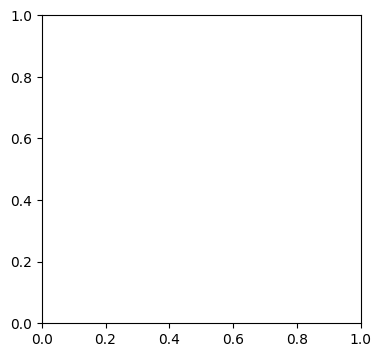

In [34]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["val_iou"], label="val_iou")
plt.legend()
plt.title("IoU")

plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["val_dice"], label="val_dice")
plt.legend()
plt.title("Dice")

plt.show()

In [35]:
best_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

best_model.load_state_dict(torch.load("best_roads_unet.pth", map_location=DEVICE))
best_model = best_model.to(DEVICE)
best_model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [36]:
test_loss, test_iou, test_dice = validate_one_epoch(best_model, test_loader, DEVICE)

print(f"test_loss = {test_loss:.4f}")
print(f"test_iou  = {test_iou:.4f}")
print(f"test_dice = {test_dice:.4f}")

test_loss = 0.1879
test_iou  = 0.6344
test_dice = 0.7535


In [37]:
@torch.no_grad()
def show_predictions(model, loader, device, n=3):
    model.eval()

    images, masks = next(iter(loader))
    images = images.to(device)

    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

    for i in range(min(n, images.size(0))):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        true_mask = masks[i, 0].cpu().numpy()
        pred_mask = preds[i, 0].numpy()

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Pred mask")
        plt.axis("off")

        plt.show()

In [38]:
threshold_results = evaluate_thresholds(model, val_loader, DEVICE)

for t, iou in threshold_results:
    print(f"threshold={t:.2f}, val_iou={iou:.4f}")

threshold=0.35, val_iou=0.6391
threshold=0.30, val_iou=0.6391
threshold=0.40, val_iou=0.6388
threshold=0.25, val_iou=0.6385
threshold=0.45, val_iou=0.6381
threshold=0.50, val_iou=0.6373
threshold=0.20, val_iou=0.6372
threshold=0.55, val_iou=0.6362
threshold=0.60, val_iou=0.6347
threshold=0.65, val_iou=0.6328
threshold=0.70, val_iou=0.6301
threshold=0.75, val_iou=0.6263
threshold=0.80, val_iou=0.6206


In [39]:
best_threshold, best_val_iou = threshold_results[0]
print("best_threshold =", best_threshold)
print("best_val_iou   =", best_val_iou)

best_threshold = 0.35
best_val_iou   = tensor(0.6391, device='cuda:0')


In [40]:
test_loss, test_iou, test_dice = validate_one_epoch(model, test_loader, DEVICE)

print(f"test_loss = {test_loss:.4f}")
print(f"test_iou  = {test_iou:.4f}")
print(f"test_dice = {test_dice:.4f}")

test_loss = 0.1896
test_iou  = 0.6378
test_dice = 0.7564


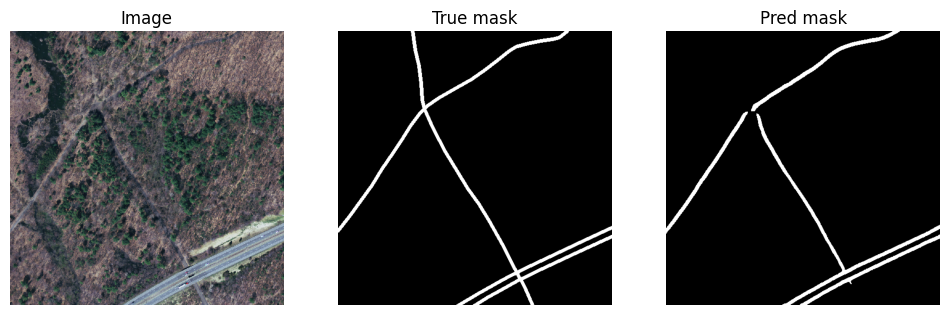

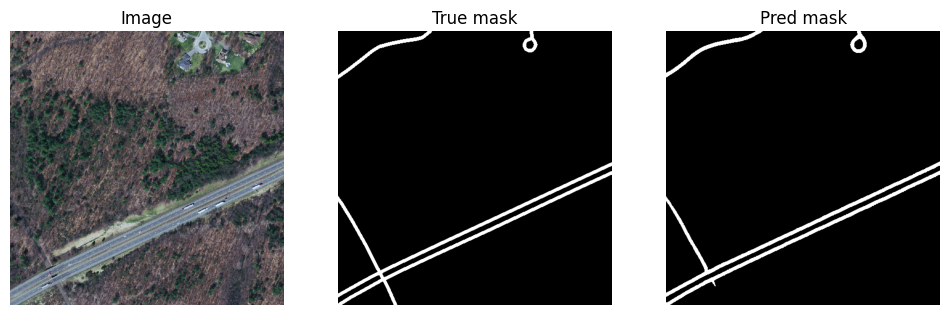

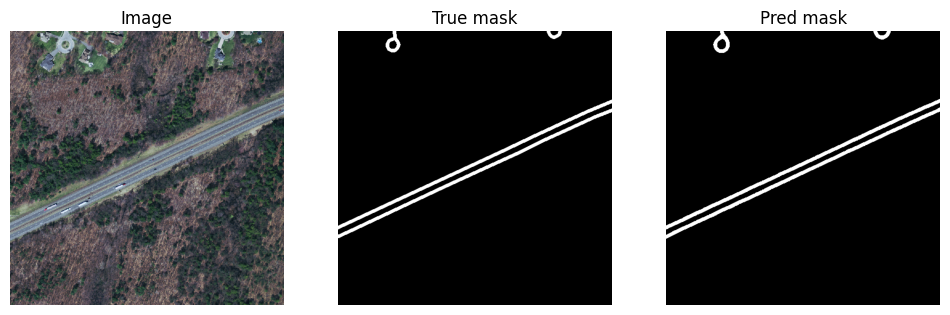

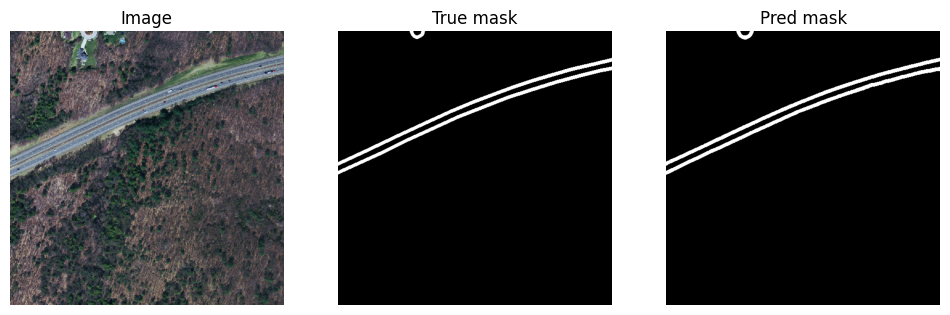

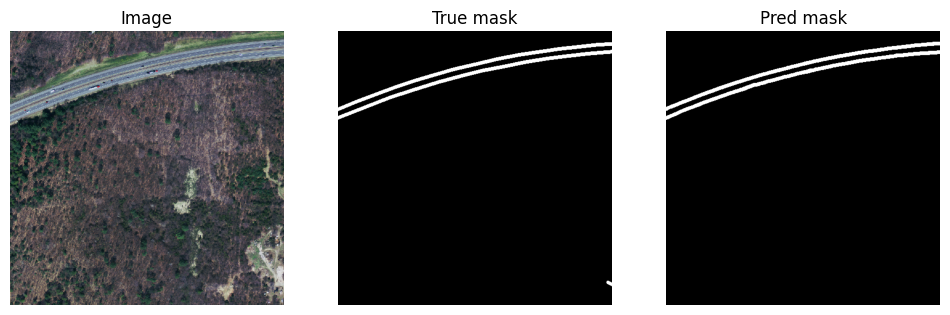

In [41]:
show_predictions(best_model, test_loader, DEVICE, n=5)